# Chronos-2 Quality Net — Results, prediction_length=4, context_length=128 (2026-08-18)

`train/finetune_chronos2.py --prediction-length 4 --context-length 128`, `eval/backtest.py
--context-length 128`로 실행한 결과입니다. prediction_length=4는 `results_context512.ipynb`에서
1보다 낫다고 확인되어 이후 실험의 기본값으로 고정했고, 이번엔 **context_length만 512(기존 기본값) →
128로 바꿨습니다**. `results_context512.ipynb`(prediction_length=4, context_length=512)와 나란히
열어서 비교하면 됩니다.

context_length=24 실험(`results_context24.ipynb`, 당시 prediction_length=1 기준)과 다르게, 이번엔
**zero-shot도 다시 평가했습니다** — context_length는 파인튜닝 여부와 무관하게 추론 시 모델에 들어가는
입력 길이 자체를 바꾸는 값이라, zero-shot도 `--context-length 128`로 새로 돌려야 결과가 달라집니다
(반면 prediction_length은 학습 시 held-out 구간 길이라 zero-shot과는 무관해서 `results_context512.ipynb`는
zero-shot을 재사용했습니다).

이 노트북은 GPU를 다시 쓰지 않습니다 — `eval/backtest_*_predlen4_ctx128_*.csv` 결과 파일만 읽습니다.

비교 대상 4가지:
- **Naive baseline**: 직전 실측값을 그대로 예측값으로 사용
- **Zero-shot**: `amazon/chronos-2` 사전학습 가중치, 파인튜닝 없음, `--context-length 128`로 평가
- **LoRA**: `--prediction-length 4 --context-length 128`로 학습 (`checkpoints/{target}_predlen4_ctx128/final`)
- **Full fine-tuning**: `--prediction-length 4 --context-length 128`, `learning_rate=1e-6` (`checkpoints/{target}_full_predlen4_ctx128/final`)

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    raise RuntimeError(
        f"config.py를 {ROOT} 에서 찾지 못했습니다. Jupyter를 chronos_quality_net 폴더에서 실행하거나, "
        "이 노트북을 그 폴더로 옮겨서 다시 여세요."
    )
sys.path.insert(0, str(ROOT))
import config as cfg

TARGETS = cfg.TARGET_COLS  # ["blaine", "residue"]
print("targets:", TARGETS)
print("spec ranges:", cfg.SPEC_RANGES)

METHOD_TAGS = {
    "zero-shot": "predlen4_ctx128_zeroshot",
    "LoRA": "predlen4_ctx128_lora",
    "Full fine-tuning": "predlen4_ctx128_full",
}
METHODS = list(METHOD_TAGS.keys())

targets: ['blaine', 'residue']
spec ranges: {'blaine': (3700.0, 3900.0), 'residue': (7.0, 9.0)}


## 1. 결과 파일 불러오기

In [2]:
EVAL_DIR = ROOT / "eval"

results = {}
for target in TARGETS:
    results[target] = {}
    for method, tag in METHOD_TAGS.items():
        p = EVAL_DIR / f"backtest_{target}_{tag}.csv"
        if p.exists():
            results[target][method] = pd.read_csv(p, parse_dates=["timestamp"])
        else:
            print(f"[missing] {p}")

for target in TARGETS:
    for method in METHODS:
        df = results[target].get(method)
        print(target, method, "->", None if df is None else f"{len(df)} rows")

blaine zero-shot -> 1007 rows
blaine LoRA -> 1007 rows
blaine Full fine-tuning -> 1007 rows
residue zero-shot -> 979 rows
residue LoRA -> 979 rows
residue Full fine-tuning -> 979 rows


## 2. 요약 지표 (MAE / RMSE / R² / Spec 정확도 / 80% 구간 커버리지)

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix


def categorize(values, lo, hi):
    return np.where((values >= lo) & (values <= hi), "IN_SPEC", "OUT_OF_SPEC")


def compute_metrics(df: pd.DataFrame, target: str, pred_col: str) -> dict:
    lo, hi = cfg.SPEC_RANGES[target]
    mae = mean_absolute_error(df["actual"], df[pred_col])
    rmse = np.sqrt(mean_squared_error(df["actual"], df[pred_col]))
    r2 = r2_score(df["actual"], df[pred_col])
    actual_cls = categorize(df["actual"].to_numpy(), lo, hi)
    pred_cls = categorize(df[pred_col].to_numpy(), lo, hi)
    spec_accuracy = float((actual_cls == pred_cls).mean())
    row = {"MAE": mae, "RMSE": rmse, "R2": r2, "spec_accuracy": spec_accuracy, "n": len(df)}
    if pred_col == "pred" and "pred_q10" in df.columns and "pred_q90" in df.columns:
        row["interval_coverage"] = float(
            ((df["actual"] >= df["pred_q10"]) & (df["actual"] <= df["pred_q90"])).mean()
        )
    else:
        row["interval_coverage"] = np.nan
    return row


rows = []
for target in TARGETS:
    first_df = next((df for df in results[target].values() if df is not None), None)
    if first_df is not None:
        rows.append({"target": target, "method": "naive", **compute_metrics(first_df, target, "naive_pred")})
    for method in METHODS:
        df = results[target].get(method)
        if df is not None:
            rows.append({"target": target, "method": method, **compute_metrics(df, target, "pred")})

summary = pd.DataFrame(rows).set_index(["target", "method"])
summary.round(4)

MAE     RMSE      R2  spec_accuracy     n  \
target  method                                                            
blaine  naive             63.2075  92.9357  0.3908         0.7259  1007   
        zero-shot         69.0347  95.8779  0.3517         0.6941  1007   
        LoRA              68.9650  95.7980  0.3527         0.6912  1007   
        Full fine-tuning  68.5077  94.9951  0.3635         0.7041  1007   
residue naive              0.4150   0.6203  0.8091         0.8131   979   
        zero-shot          0.4443   0.6278  0.8045         0.7814   979   
        LoRA               0.4435   0.6260  0.8056         0.7824   979   
        Full fine-tuning   0.4401   0.6171  0.8111         0.7886   979   

                          interval_coverage  
target  method                               
blaine  naive                           NaN  
        zero-shot                    0.4578  
        LoRA                         0.4578  
        Full fine-tuning             0.5134  
residue naive                           NaN  
        zero-shot                    0.4556  
        LoRA                         0.4637  
        Full fine-tuning             0.4923

## 3. 방식별 비교 막대그래프 (MAE, RMSE, Spec 정확도)

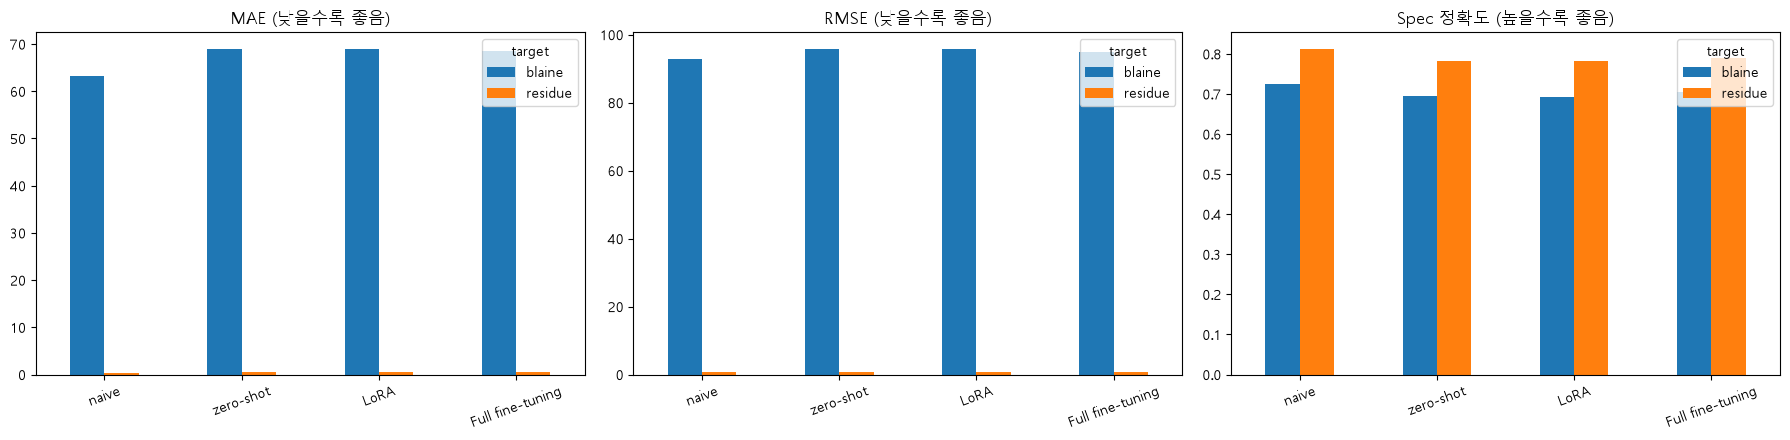

In [4]:
method_order = ["naive"] + METHODS
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

metrics = ["MAE", "RMSE", "spec_accuracy"]
titles = ["MAE (낮을수록 좋음)", "RMSE (낮을수록 좋음)", "Spec 정확도 (높을수록 좋음)"]
for ax, metric, title in zip(axes, metrics, titles):
    plot_df = summary[metric].unstack("target").reindex(method_order)
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(title="target")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 4. 실제값 vs 예측값 산점도 (naive / zero-shot / LoRA / full)

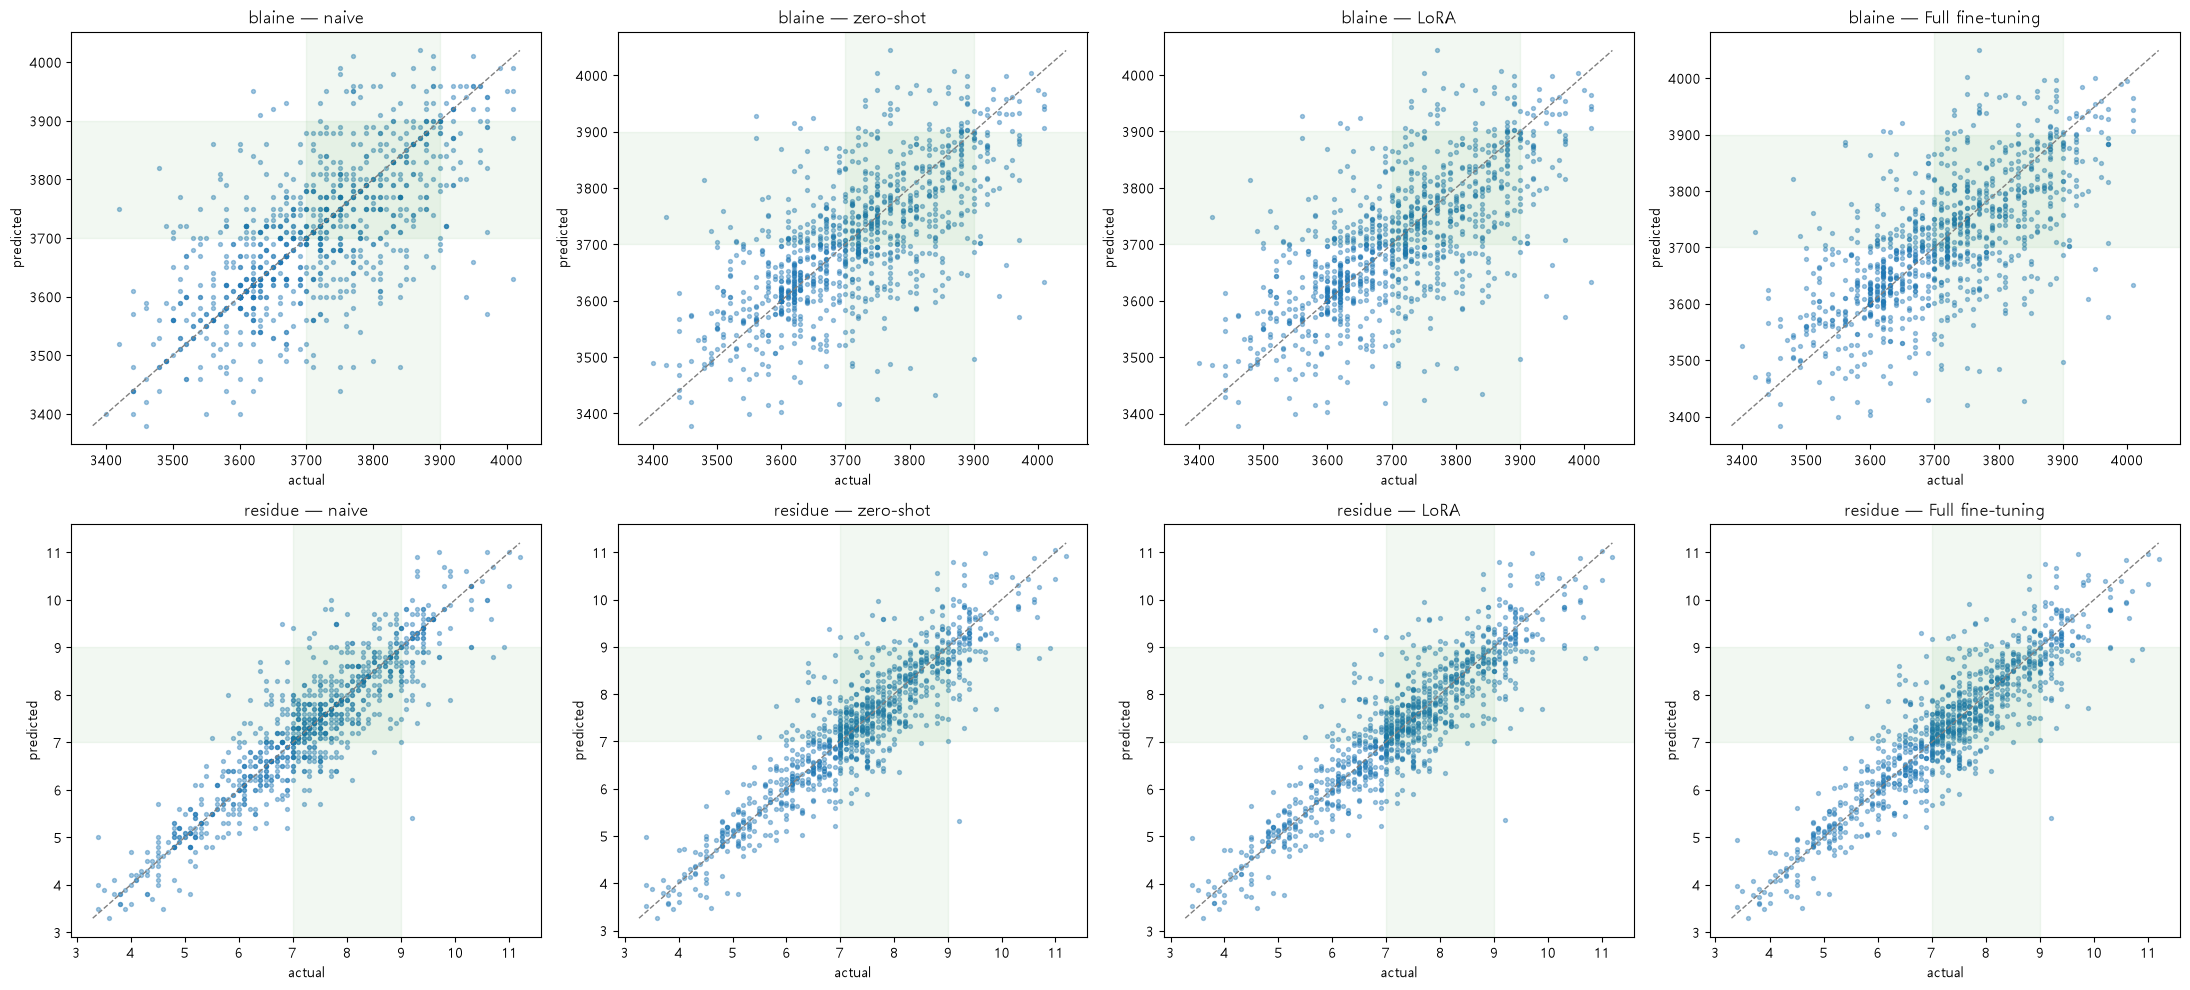

In [5]:
fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(5.5 * (1 + len(METHODS)), 5 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        ax.scatter(df["actual"], df[pred_col], s=8, alpha=0.4)
        lims = [min(df["actual"].min(), df[pred_col].min()), max(df["actual"].max(), df[pred_col].max())]
        ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1)
        ax.axvspan(lo, hi, color="green", alpha=0.05)
        ax.axhspan(lo, hi, color="green", alpha=0.05)
        ax.set_title(f"{target} — {label}")
        ax.set_xlabel("actual")
        ax.set_ylabel("predicted")

plt.tight_layout()
plt.show()

## 5. 시계열: 실제값 vs 예측 + 80% 예측구간 (full fine-tuning 모델, 호기별)

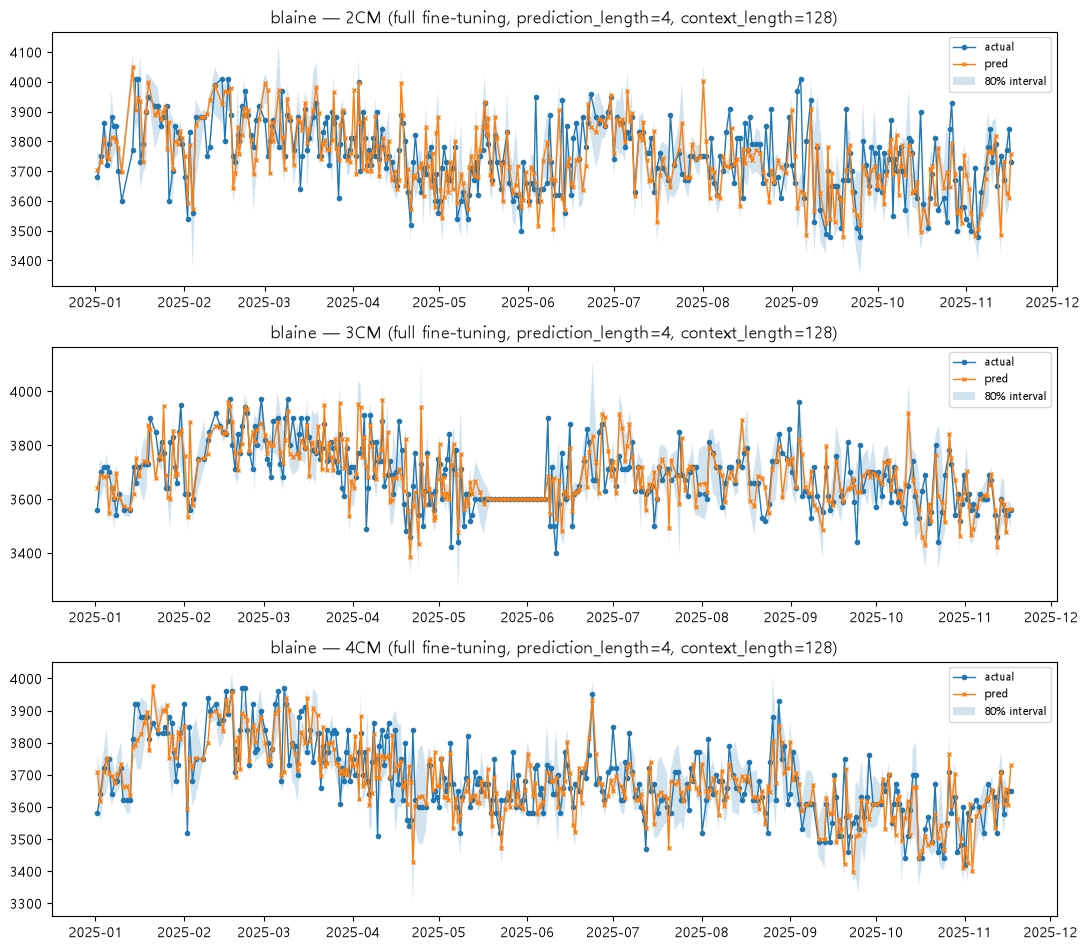

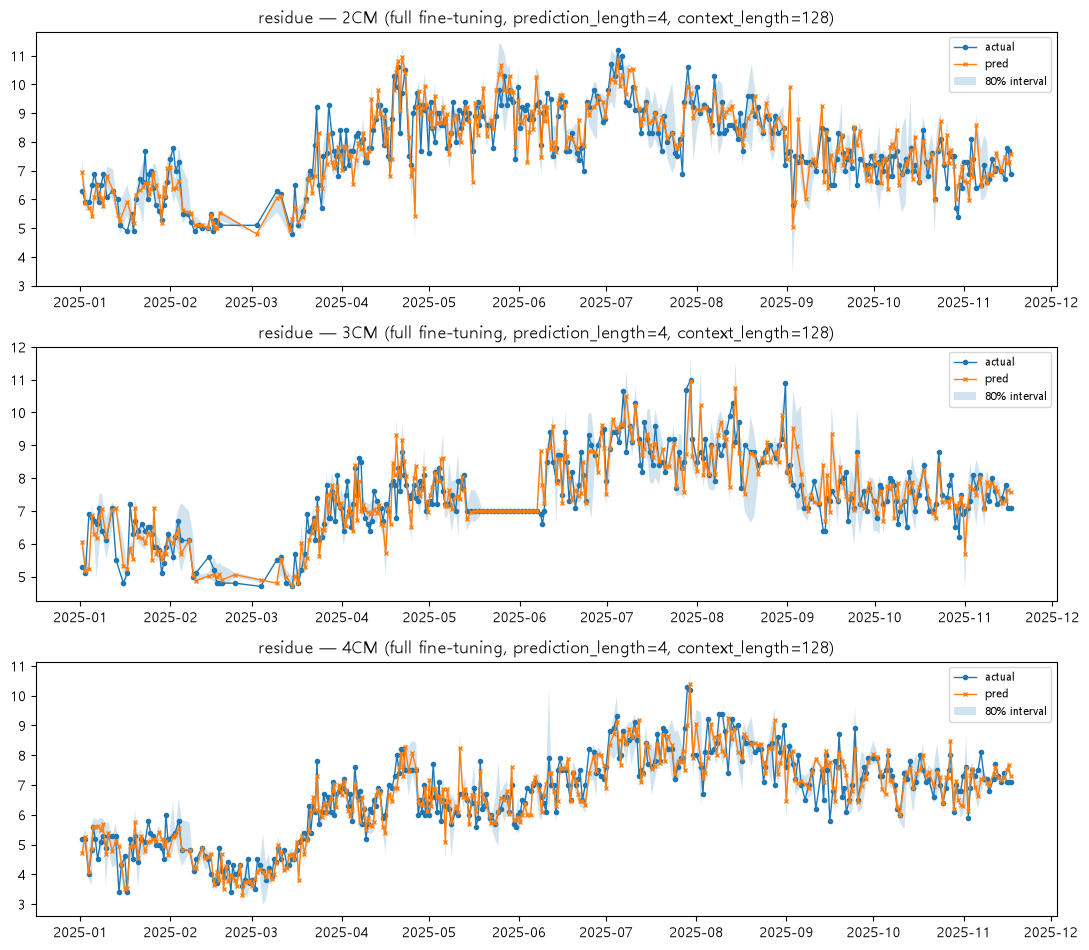

In [6]:
for target in TARGETS:
    df = results[target].get("Full fine-tuning")
    if df is None:
        continue
    item_ids = sorted(df["item_id"].unique())
    fig, axes = plt.subplots(len(item_ids), 1, figsize=(11, 3.2 * len(item_ids)), sharex=False)
    if len(item_ids) == 1:
        axes = [axes]
    for ax, item_id in zip(axes, item_ids):
        g = df[df["item_id"] == item_id].sort_values("timestamp")
        ax.plot(g["timestamp"], g["actual"], label="actual", marker="o", markersize=3, linewidth=1)
        ax.plot(g["timestamp"], g["pred"], label="pred", marker="x", markersize=3, linewidth=1)
        ax.fill_between(g["timestamp"], g["pred_q10"], g["pred_q90"], alpha=0.2, label="80% interval")
        ax.set_title(f"{target} — {item_id} (full fine-tuning, prediction_length=4, context_length=128)")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. Confusion Matrix (Spec-in / Spec-out)

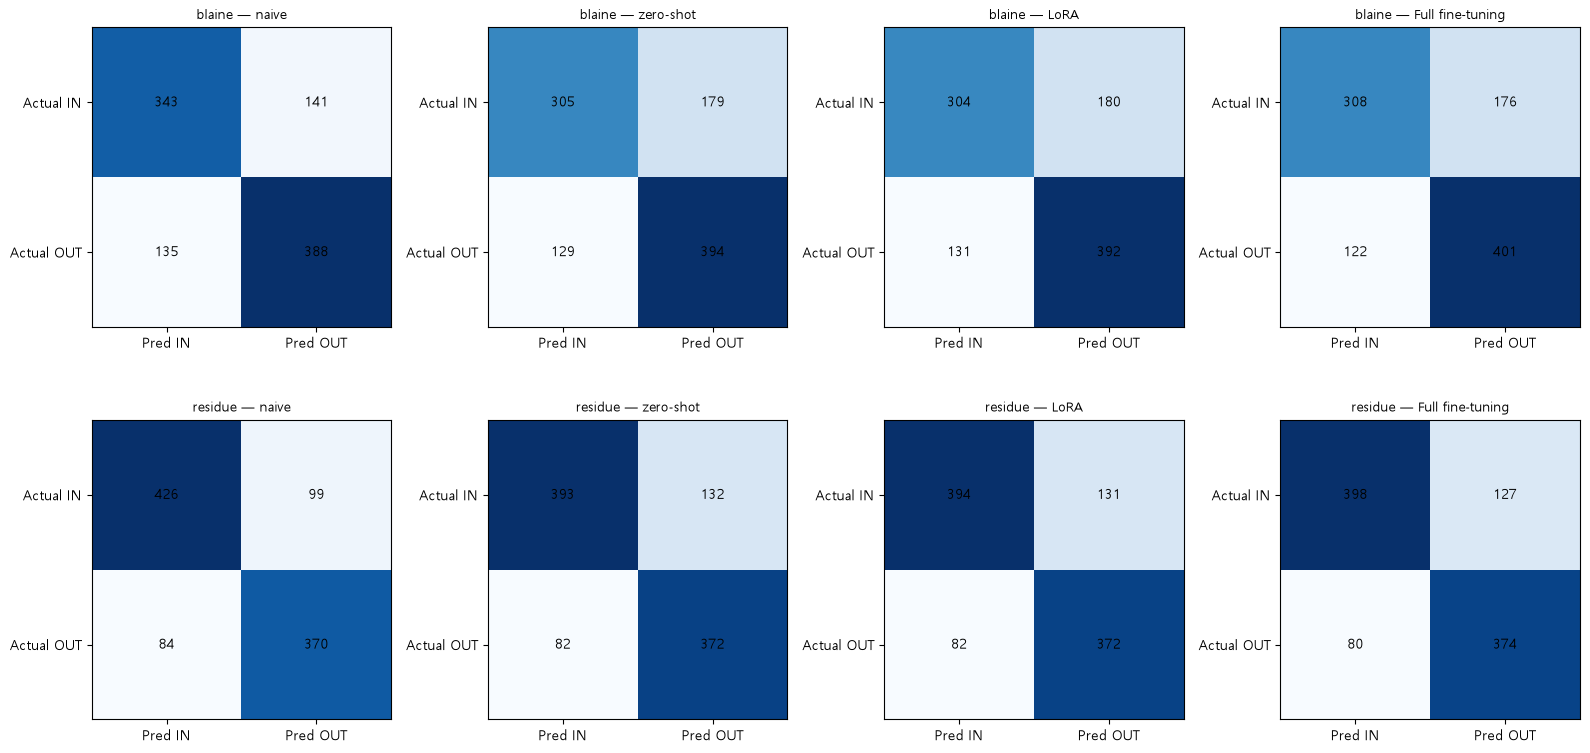

In [7]:
def plot_cm(ax, actual, pred, lo, hi, title):
    actual_cls = categorize(actual, lo, hi)
    pred_cls = categorize(pred, lo, hi)
    cm = confusion_matrix(actual_cls, pred_cls, labels=["IN_SPEC", "OUT_OF_SPEC"])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred IN", "Pred OUT"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual IN", "Actual OUT"])
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(4 * (1 + len(METHODS)), 4 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        plot_cm(ax, df["actual"].to_numpy(), df[pred_col].to_numpy(), lo, hi, f"{target} — {label}")

plt.tight_layout()
plt.show()

## 7. 결론

- **context_length를 512(prediction_length=4 기준)에서 128로 줄이니 두 타깃 모두 뚜렷하게 나빠졌습니다.**
  blaine MAE는 full 기준 64.18(ctx512) → 68.51(ctx128), R²는 0.4550 → 0.3635로 크게 악화. residue도
  MAE 0.4298 → 0.4401, R² 0.8295 → 0.8111로 악화됐습니다. `results_context24.ipynb`의 결론("context를
  줄이면 손해")이 prediction_length=4로 고정한 뒤에도 다시 확인된 셈입니다.
- **흥미로운 점**: ctx128(prediction_length=4)이 예전 ctx24(prediction_length=1) 결과보다도 대체로
  못하거나 비슷합니다 — blaine Full MAE는 ctx24 67.80 vs ctx128 68.51(ctx128이 오히려 더 나쁨), residue
  Full MAE는 ctx24 0.4501 vs ctx128 0.4401(ctx128이 더 나음). 즉 prediction_length=4로의 개선 효과가
  context_length를 128까지 줄인 손해를 항상 상쇄하지는 못합니다 — 특히 blaine에서는 context 부족이 더
  치명적입니다.
- **80% 예측구간 커버리지는 ctx512보다는 낮지만 ctx24보다는 조금 나은 수준**(45~51%)으로, context_length와
  prediction_length 두 요인이 커버리지에 서로 다른 방향으로 영향을 주는 것으로 보입니다.
- **LoRA와 Full 격차가 ctx512 때보다 좁습니다** — blaine 기준 LoRA MAE 68.97 vs Full 68.51(차이 0.46),
  ctx512에서는 LoRA 66.31 vs Full 64.18(차이 2.13)였던 것과 비교하면, context가 짧아지면 파인튜닝 방식
  간 차이 자체도 줄어드는 것으로 보입니다(학습으로 살릴 수 있는 여지 자체가 context 부족으로 제한되는 것으로 추정).
- 종합하면 **context_length=128은 기각** — 지금까지 실험한 조합 중 context_length=512, prediction_length=4
  (`results_context512.ipynb`)가 여전히 최고 성능입니다.

prediction_length=4, context_length=512 결과는 `results_context512.ipynb`, context_length=24
(prediction_length=1) 결과는 `results_context24.ipynb`, 기준선(prediction_length=1, context_length=512)은
`results.ipynb` 참고.